
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión. 

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div> 


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success"> 
<b>COMENTARIO GENERAL #2</b> <a class="tocSkip"></a>

Felicidades Javier! Tu trabajo es excelente. 

Has completado todos los items necesarios para aprobar la entrega.

He dejado varios comentarios que espero te sean de utilidad.

Sigue así!

</div>

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Considera añadir una breve introducción del proyecto antes de la sección de inicialización: plantea la pregunta de negocio (qué plan genera más ingresos), resume los conjuntos de datos que usarás y describe los pasos principales del análisis (preparación de datos → agregación mensual con reglas de facturación → cálculo de ingresos → comparación de comportamiento → pruebas de hipótesis → conclusión). Esto ayuda a que el notebook se lea como un informe cohesivo, en lugar de pasar directamente al código.

</div>


## Inicialización

In [1]:
# Para trabajar con los data set
import pandas as pd
# Para hacer cálculos (varianzas, medias, desviación estandar...)
import numpy as np
# Para hacer test de valor p e hipótesis
from scipy import stats as st
# Para graficar
import matplotlib.pyplot as plt
# Por si me pongo más creativo al graficar
import seaborn as sns

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Buen trabajo al separar la importación de bibliotecas de la carga de los datasets! Esto mejora la estructura y claridad de tu código.

</div>

## Cargar datos

Cargo a variable cada archivo `.csv` con la herramienta `.read_csv`.

In [2]:
# Cargo los data sets con read_csv cada data set
users = pd.read_csv('/datasets/megaline_users.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')
plans = pd.read_csv('/datasets/megaline_plans.csv')

## Preparar los datos

En este punto se revisan la estructura de los datos de cada data set y se realizan las transformaciones necesarias sobre el tipo de dato cuando corresponda, busqueda de duplicados, reasignación-eliminación de valores ausentes, errores de tipado, enrriquecimiento con nuevas columnas para facilitar la exploración etc

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
print(plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes
None


Hay que revisar las columnas `usd_per_message` y `usd_per_minute` por los conceptos que reflejan parece lógico pensar que puedan el precio pueda, ser fracciones de $1

In [4]:
# Imprime una muestra de los datos para las tarifas
print(plans.head())

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


La tabla de planes tiene una esctructura sólida. Los valores que muestran las columnas `usd_per_message` y `usd_per_minute` son efectivamente fracciones de $1, no es necesario hacer transformaciones en las columnas ya incluidas.

## Corregir datos

No veo problemas con el tipo de datos, no hay duplicados ni valores ausentes.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Buen trabajo documentando tu revisión de la tabla de planes (info + muestra) y comprobando explícitamente las columnas de precios potencialmente complicadas. Tu conclusión de que aquí no se necesitan correcciones está bien fundamentada.

</div>


## Enriquecer los datos

Creo que podría ser util añadir una tabla que refleje el coste de por mb cuando se supera la tarifa.

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Excelente idea de *feature engineering*: derivar un costo por MB a partir de `usd_per_gb` usando la conversión 1 GB = 1024 MB mantiene las unidades consistentes y puede hacer que los cálculos posteriores sean más claros (especialmente cuando partes de un uso a nivel de MB).

</div>


In [5]:
# Creo la columna usd_per_mb y calculo su valor a traves de recorrer usd_per_gb
# Con la equivalencia de 1gb = 1024 mb
plans['usd_per_mb'] = plans['usd_per_gb']/1024
plans['usd_per_mb']

0    0.009766
1    0.006836
Name: usd_per_mb, dtype: float64

Creo que podría ser util añadir una tabla que refleje los gb incluidos por tarifa

In [6]:
# Creo la columna gb_per_month include
plans['gb_per_month_included'] = plans['mb_per_month_included']/1024
plans['gb_per_month_included']

0    15.0
1    30.0
Name: gb_per_month_included, dtype: float64

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


Revisando el tipo de dato para las columnas `#5` y `#7` muestra tipo str, al ser conceptos de fechas hay que inspeccionarlas para ver si se pueden transformar a algún tipo fecha.

La columna `churn_date` contiene muchísimos valores ausentes, al referirse al concepto "fecha de baja del servicio" se puede asumir que al no haberse producido baja el dato es en efecto ausente. Convetiré los datos que puedan ser fechas con date_time

Para el resto de columnas haré algo predeterminado, buscando valores duplicados, errores de tipado, valores ausentes si hubiera aunque no es el caso...

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Al describir problemas de datos en `users`, haz explícita la cadena “problema → decisión → corrección”. En particular, aclara que los valores faltantes de `churn_date` son esperados (el usuario aún no ha churned) e indica qué harás con ellos después de la conversión (p. ej., mantenerlos como `NaT` en lugar de rellenarlos), y por qué.

</div>


In [8]:
# Imprime una muestra de datos para usuarios
users.tail(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN
498,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN
499,1499,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN


Esta muestra en concreto parece que el único problema es la fecha de baja de `churn_date` que muestra un valor ausente.

Se me ocurre crear una columna alternativa a `city` que muestre los nombres de las ciudades con iniciales, para poder hacer consultas que ocupen menos espacio en el código.

### Corregir los datos

Reviso valores minimos y máximos en la columna `age`, pura curiosidad y ver si hay valores atípicos

In [9]:
print('Valor minímo en age',users['age'].min())
print('Valor máximo en age',users['age'].max())

Valor minímo en age 18
Valor máximo en age 75


Valores de edad coherentes.

Reviso si hay filas duplicadas.

In [10]:
print('Número de filas duplicadas: ', users.duplicated().sum())

Número de filas duplicadas:  0


Sin filas duplicadas

Reviso los casos únicos para `city` por si hubiera algún error de tipado y transformalo si fuera necesario.

In [11]:
sorted(users['city'].unique())

['Albany-Schenectady-Troy, NY MSA',
 'Albuquerque, NM MSA',
 'Atlanta-Sandy Springs-Roswell, GA MSA',
 'Austin-Round Rock-Georgetown, TX MSA',
 'Bakersfield, CA MSA',
 'Baltimore-Columbia-Towson, MD MSA',
 'Baton Rouge, LA MSA',
 'Birmingham-Hoover, AL MSA',
 'Boston-Cambridge-Newton, MA-NH MSA',
 'Bridgeport-Stamford-Norwalk, CT MSA',
 'Buffalo-Cheektowaga, NY MSA',
 'Cape Coral-Fort Myers, FL MSA',
 'Charleston-North Charleston, SC MSA',
 'Charlotte-Concord-Gastonia, NC-SC MSA',
 'Chicago-Naperville-Elgin, IL-IN-WI MSA',
 'Cincinnati, OH-KY-IN MSA',
 'Cleveland-Elyria, OH MSA',
 'Colorado Springs, CO MSA',
 'Columbia, SC MSA',
 'Columbus, OH MSA',
 'Dallas-Fort Worth-Arlington, TX MSA',
 'Dayton-Kettering, OH MSA',
 'Denver-Aurora-Lakewood, CO MSA',
 'Detroit-Warren-Dearborn, MI MSA',
 'El Paso, TX MSA',
 'Fresno, CA MSA',
 'Grand Rapids-Kentwood, MI MSA',
 'Greensboro-High Point, NC MSA',
 'Houston-The Woodlands-Sugar Land, TX MSA',
 'Indianapolis-Carmel-Anderson, IN MSA',
 'Jackson

Sin errores ni duplicados implicitos.

Igual para `plan` reviso por si hubiera algún error de tipado y transformalo si fuera necesario.

In [12]:
sorted(users['plan'].unique())

['surf', 'ultimate']

Dos casos únicos, lo esperado.

### Enriquecer los datos

Transformo la columna `churn_date` tipo fecha para poder hacer consultas facilmente.

In [13]:
users[users['churn_date'].notnull()].head(1)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
6,1006,Jesusa,Bradford,73,"San Francisco-Oakland-Berkeley, CA MSA",2018-11-27,ultimate,2018-12-18


format = '%Y-%m-%d'

In [14]:
# Fuerzo la conversión de los valores que se puedan convertir a fecha
users['churn_date'] = pd.to_datetime(users['churn_date'],format = '%Y-%m-%d', errors = 'coerce')

<div class="alert alert-block alert-success">
<b>Comentario Revisor #2</b> <a class="tocSkip"></a>

Excelente trabajo al agregar el argumento "format='%Y-%m-%d'" dentro de la función to_datetime(). De esta manera, puedes asegurarte siempre de que el formato de la fecha que deseas cambiar sea el que necesitas.
</div>

Transformación de la columna `reg_date` a tipo fecha

In [15]:
# Visualizo para ver el formato de la fecha
users['reg_date'].head(1)

0    2018-12-24
Name: reg_date, dtype: object

format = '%Y-%m-%d'

In [16]:
users['reg_date'] = pd.to_datetime(users['reg_date'], format = '%Y-%m-%d')
users['reg_date'].head(1)

0   2018-12-24
Name: reg_date, dtype: datetime64[ns]

Añado una nueva columna `city_code` que solo contenga los acrónimos de las ciudades para hacer que el código al consultar ciudades sea más corto.

In [17]:
# Divido la columna 'city' por la coma
city_code = users['city'].str.split(',')
# Quito espacios y divido el segundo str de la lista por el espacio
city_code = city_code.apply(lambda x: [s.strip().split(' ') for s in x])
# Asigno el segundo elemento de la columna original a una nueva columna llamada city_code
users['city_code'] = city_code.apply(lambda x: x[1][0])
sorted(users['city_code'].unique())

['AL',
 'AZ',
 'CA',
 'CO',
 'CT',
 'DC-VA-MD-WV',
 'FL',
 'GA',
 'HI',
 'IL-IN-WI',
 'IN',
 'KY-IN',
 'LA',
 'MA-NH',
 'MD',
 'MI',
 'MN-WI',
 'MO-IL',
 'MO-KS',
 'NC',
 'NC-SC',
 'NE-IA',
 'NM',
 'NV',
 'NY',
 'NY-NJ-PA',
 'OH',
 'OH-KY-IN',
 'OK',
 'OR-WA',
 'PA',
 'PA-NJ-DE-MD',
 'RI-MA',
 'SC',
 'TN',
 'TN-MS-AR',
 'TX',
 'UT',
 'VA',
 'VA-NC',
 'WA',
 'WI']

Cuando haga consultas sobre ciudades-regiones me será útil.

## Llamadas

In [18]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [19]:
# Imprime una muestra de datos para las llamadas
calls.head(5)

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [20]:
print(calls['call_date'].min())
print(calls['call_date'].max())

2018-01-15
2018-12-31


El tipo de dato para `call_date` se muestra que es str, hay que inspeccionar y ver si se puede cambiar a tipo fecha.

Las columnas no tiene valores ausentes porque coincidn los valores non-null con entries lo que muestra una recolección solida de los datos, a falta de comprobar duplicados, errores de tipado, valores atípicos...

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Regla importante de facturación a incorporar para las llamadas: la duración de cada llamada individual debe redondearse hacia arriba al siguiente minuto completo antes de agregar por mes. Si sumas minutos fraccionarios sin redondear, los minutos mensuales (y los ingresos) se subestimarán.

</div>


### Corregir los datos

Reviso si hay filas duplicadas

In [21]:
sum_duplicated_calls = calls.duplicated().sum()
print('El número de filas duplicadas para calls es: ', sum_duplicated_calls)

El número de filas duplicadas para calls es:  0


In [22]:
print('Valor minímo en duration',calls['duration'].min())
print('Valor máximo en duration',calls['duration'].max())

Valor minímo en duration 0.0
Valor máximo en duration 37.6


### Enriquecer los datos

Añado una columna con la duración de llamadas redondeada para la facturación, como se 

In [23]:
calls['duration_round'] = np.ceil(calls['duration'])

Convierto el tipo de dato de la columna `call_date` a tipo fecha por si hay que hacer algún cálculo.

In [24]:
calls['call_date'].head(1)

0    2018-12-27
Name: call_date, dtype: object

format = '%Y-%m-%d'

In [25]:
calls['call_date'] = pd.to_datetime(calls['call_date'], format = '%Y-%m-%d')
calls['call_date'].head(1)

0   2018-12-27
Name: call_date, dtype: datetime64[ns]

## Mensajes

In [26]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [27]:
# Imprime una muestra de datos para los mensajes
messages.head(5)

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


Sin valores ausentes, hay que comprobar duplicados, errores de tipado, valores atípicos...

Para la columna `message_date` hay que cambiarla a tipo fecha.

### Corregir los datos

Entries coincide con no-null por lo tanto no hay valores ausentes en ninguna columna.

Comprobaré duplicados.

In [28]:
print('Número de filas duplicadas: ', messages.duplicated().sum())

Número de filas duplicadas:  0


### Enriquecer los datos

Voy a cambiar la columna `messsage_date` a tipo fecha.

In [29]:
messages['message_date'].head(1)

0    2018-12-27
Name: message_date, dtype: object

format = '%Y-%m-%d'

In [30]:
messages['message_date'] = pd.to_datetime(messages['message_date'], format = '%Y-%m-%d')
messages['message_date'].head(1)

0   2018-12-27
Name: message_date, dtype: datetime64[ns]

## Internet

In [31]:
# Imprime la información general/resumida sobre el DataFrame de internet
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Después de imprimir `.info()` de la tabla Internet y una muestra, añade una breve interpretación escrita en el notebook (tipos, valores faltantes, cualquier valor sospechoso como sesiones de 0 MB, y qué planeas convertir/arreglar). Las comprobaciones están en su mayor parte en el código, pero en este punto falta la explicación narrativa requerida.

</div>


In [32]:
# Imprime una muestra de datos para el tráfico de internet
internet.sample(6)

,id,user_id,session_date,mb_used
65041,1299_329,1299,2018-08-21,474.66
57308,1258_350,1258,2018-07-27,115.96
7507,1041_347,1041,2018-04-15,492.44
5440,1030_39,1030,2018-11-01,0.00
55175,1250_39,1250,2018-10-18,876.78
24156,1110_414,1110,2018-07-05,335.35


Sin valores ausentes (entries coincide con no-nulls para todas las columnas), hay que comprobar duplicados, errores de tipado, valores atípicos...

Para la columna `session_date` hay que cambiarla a tipo fecha.

### Corregir los datos

Compruebo duplicados

In [33]:
print('Cantidad de filas duplicadas: ', internet.duplicated().sum())

Cantidad de filas duplicadas:  0


### Enriquecer los datos

Columna `session_date` la cambio a tipo fecha.

In [34]:
internet['session_date'].head(1)

0    2018-12-29
Name: session_date, dtype: object

In [35]:
internet['session_date'] = pd.to_datetime(internet['session_date'], format = '%Y-%m-%d')
internet['session_date'].tail(1)

104824   2018-12-24
Name: session_date, dtype: datetime64[ns]

Añado la columna `gb_used` para poder reflejar el consumo con una escala diferente.

In [36]:
internet['gb_used'] = internet['mb_used']/1024
internet['gb_used'].head()

0    0.087754
1    0.000000
2    0.644922
3    0.264639
4    0.859590
Name: gb_used, dtype: float64

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Bien hecho, convertiste las columnas a los tipos de datos adecuados (fechas, enteros, etc.) e hiciste los cambios esperados. Esto evita errores en cálculos posteriores. 

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Como recomendación, documenta siempre por qué haces cada conversión para dejar trazabilidad.

</div>

</div>

## Estudiar las condiciones de las tarifas

In [37]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_per_mb,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,0.006836,30.0


Con el redondeo de las llamadas individuales se pueden calcular los ingresos por usuario

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Además de imprimir los planes, confirma explícitamente en el texto que tus cálculos posteriores seguirán las reglas de redondeo (llamadas redondeadas hacia arriba por llamada; internet redondeado hacia arriba al GB completo por mes). Además, considera señalar el mapeo de columnas entre la redacción de la plantilla y tu tabla (por ejemplo, `usd_monthly_pay` como la tarifa mensual) para que la fórmula de ingresos no sea ambigua.

</div>


## Agregar datos por usuario

In [38]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

# Creo columna con el mes (año-mes)
calls['month'] = calls['call_date'].dt.strftime('%B')

# Agrupo por usuario y mes
calls_per_user_month = calls.groupby(['user_id', 'month']).size().reset_index(name='calls_count')

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la agregación mensual, usar nombres de meses (p. ej., “December”) es frágil para ordenar y no se generaliza si aparecen varios años. Considera agrupar por un mes numérico o por un período año-mes (p. ej., `2018-12`) para mantener claros el orden temporal y la unicidad.

</div>


In [39]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutes_per_user_month = calls.groupby(['user_id','month'])['duration_round'].sum().reset_index(name = 'minutes_used')

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente (regla de facturación): los minutos mensuales se están calculando a partir del `duration` en bruto sin redondear primero cada llamada hacia arriba. Aplica el redondeo por llamada antes de la suma mensual para que coincida con cómo se factura a los clientes.

</div>


In [40]:
# Creo la columna month para messages
messages['month'] = messages['message_date'].dt.strftime('%B')
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
messages_per_user_month = messages.groupby(['user_id', 'month']).size().reset_index(name='message_count')

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Muy buen trabajo al utilizar el atributo _name_ del método `reset_index` para especificar un nombre de columna al valor agregado.

</div>

In [41]:
internet['month'] = internet['session_date'].dt.strftime('%B')
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
internet_per_user_month = internet.groupby(['user_id','month'])['gb_used'].sum().reset_index(name = 'total_gb_month')
# Se incluye el redondeo de los gb mensuales y se crea una columna altenativa total_gb_month_round
internet_per_user_month['total_gb_month_round'] = np.ceil(internet_per_user_month['total_gb_month'])
internet_per_user_month

,user_id,month,total_gb_month,total_gb_month_round
0,1000,December,1.856904,2.0
1,1001,August,6.756982,7.0
2,1001,December,18.915215,19.0
3,1001,November,18.070605,19.0
4,1001,October,21.807119,22.0
...,...,...,...,...
2272,1498,September,22.292266,23.0
2273,1499,December,21.542197,22.0
2274,1499,November,16.419756,17.0
2275,1499,October,19.035576,20.0


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la facturación de Internet, el redondeo se aplica al total mensual (se suma el uso del mes y luego se redondea hacia arriba a GB completos). Sumar los GB por sesión y mantener un total mensual fraccionario no coincidirá con las reglas de facturación utilizadas para calcular los cargos.

</div>


In [42]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# Empezamos con llamadas
monthly = calls_per_user_month.copy()
# Añadimos minutos
monthly = monthly.merge(minutes_per_user_month,
                        on=['user_id', 'month'],
                        how='outer')

# Añadimos SMS
monthly = monthly.merge(messages_per_user_month,
                        on=['user_id', 'month'],
                        how='outer')

# Añadimos Internet
monthly = monthly.merge(internet_per_user_month,
                        on=['user_id', 'month'],
                        how='outer')

monthly = monthly.fillna(0)

# Unir con users
monthly = monthly.merge(users[['user_id', 'plan']],
                        on='user_id',
                        how='outer')

print(monthly)

      user_id     month  calls_count  minutes_used  message_count  \
0        1000  December         16.0         124.0           11.0   
1        1001    August         27.0         182.0           30.0   
2        1001  December         56.0         412.0           44.0   
3        1001  November         64.0         426.0           36.0   
4        1001   October         65.0         393.0           53.0   
...       ...       ...          ...           ...            ...   
2298     1307       NaN          NaN           NaN            NaN   
2299     1319       NaN          NaN           NaN            NaN   
2300     1378       NaN          NaN           NaN            NaN   
2301     1463       NaN          NaN           NaN            NaN   
2302     1473       NaN          NaN           NaN            NaN   

      total_gb_month  total_gb_month_round      plan  
0           1.856904                   2.0  ultimate  
1           6.756982                   7.0      surf  
2     

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La forma en que se construye la tabla mensual (empezando por `calls` y haciendo `left-merge` con las demás) elimina los user-months en los que un usuario tuvo 0 llamadas pero sí usó SMS o internet. Para realmente tener un registro por usuario por mes, considera hacer `outer-merge` de todos los agregados (o construir primero un índice completo de user-month) antes de rellenar el uso faltante con ceros.

</div>


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Bien visto! En este caso claramente debemos utilizar _outer_ al realizar los merge.

</div>

In [43]:
# Añade la información de la tarifa
# Unir con plans
monthly = monthly.merge(plans,
                        left_on='plan',
                        right_on='plan_name',
                        how='left')
monthly

,user_id,month,calls_count,minutes_used,message_count,total_gb_month,total_gb_month_round,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_per_mb,gb_per_month_included
0,1000,December,16.0,124.0,11.0,1.856904,2.0,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,0.006836,30.0
1,1001,August,27.0,182.0,30.0,6.756982,7.0,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
2,1001,December,56.0,412.0,44.0,18.915215,19.0,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
3,1001,November,64.0,426.0,36.0,18.070605,19.0,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
4,1001,October,65.0,393.0,53.0,21.807119,22.0,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2298,1307,NaN,NaN,NaN,NaN,NaN,NaN,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
2299,1319,NaN,NaN,NaN,NaN,NaN,NaN,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
2300,1378,NaN,NaN,NaN,NaN,NaN,NaN,surf,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
2301,1463,NaN,NaN,NaN,NaN,NaN,NaN,ultimate,1000,30720,3000,70,7,0.01,0.01,ultimate,0.006836,30.0


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Bien, en esta parte basta con el uso de left ya que la data de consumo de usuarios ya está completa.


</div>

Calculo del ingreso mensual por usuario

In [44]:
# Calcula el ingreso mensual para cada usuario
# total_gasto_user = usd_monthly_pay + (extra_min * usd_per_minute) + (extra_messages * usd_per_message) + (extra_gb * usd_per_gb)

# Calculo de forma vectorizada con pandas cada valor por usuario de minutos, mensajes y gb extra
# con clip() índico el valor limite inferior para la resta en 0 para los casos en los que es cáculo sea un valor negativo
monthly['extra_min'] = (monthly['minutes_used'] - monthly['minutes_included']).clip(lower = 0)
monthly['extra_messages'] = (monthly['message_count'] - monthly['messages_included']).clip(lower = 0)
monthly['extra_gb'] = (monthly['total_gb_month_round'] - monthly['gb_per_month_included']).clip(lower = 0)

# Calculo el consumo por concepto utilizando las columnas asociadas

monthly['gasto_llamadas'] = monthly['extra_min'] * monthly['usd_per_minute']
monthly['gasto_mensajes'] = monthly['extra_messages'] * monthly['usd_per_message']
monthly['gasto_internet'] = monthly['extra_gb'] * monthly['usd_per_gb']

monthly['gasto_total_mes'] = monthly['usd_monthly_pay'] + monthly['gasto_llamadas'] + monthly['gasto_mensajes'] + monthly['gasto_internet']

resumen_gasto = monthly[['user_id','plan','gasto_total_mes']]

print(resumen_gasto.sample(6))
print()
print('El caso de menos consumo es:','$', round(monthly['gasto_total_mes'].min(),2))
print('El caso de más consumo es:','$', round(monthly['gasto_total_mes'].max(),2))
print('La media de consumo es:','$', round(monthly['gasto_total_mes'].mean(),2))
print('La mediana de consumo es:','$', round(monthly['gasto_total_mes'].median(),2))
print('La desviación estandar de consumo es:','$', round(monthly['gasto_total_mes'].std(),2))

      user_id      plan  gasto_total_mes
998      1214  ultimate            70.00
2208     1490  ultimate           133.00
1731     1381      surf            83.63
1922     1416      surf            40.00
1408     1313      surf            36.39
240      1055      surf            20.72

El caso de menos consumo es: $ 20.0
El caso de más consumo es: $ 590.37
La media de consumo es: $ 64.35
La mediana de consumo es: $ 70.0
La desviación estandar de consumo es: $ 46.62


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Calculaste correctamente las métricas mensuales por usuario (llamadas, SMS, datos e ingresos). Esto es clave para comparar planes.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Como práctica profesional, intenta empaquetar estos cálculos en funciones para reutilizarlos fácilmente.

</div>

</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Problema recurrente (facturación de internet): `extra_gb` se calcula a partir de un `total_gb_month` fraccionario. Dado que la facturación es por GB iniciado, primero debes calcular los GB mensuales facturados como el techo (ceiling) del total mensual y, después, calcular el exceso (overage) a partir de ese importe facturado.

</div>


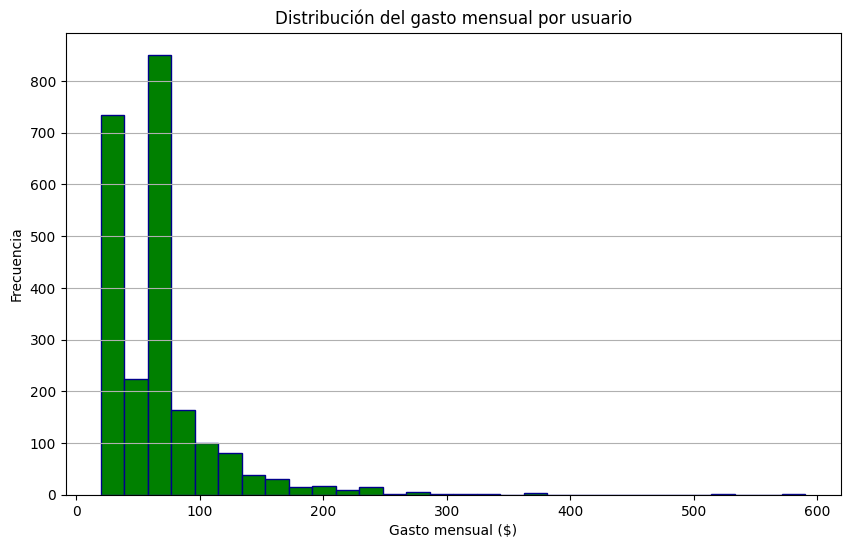

In [45]:
plt.figure(figsize=(10,6))
plt.hist(monthly['gasto_total_mes'], color = 'green', bins=30, linewidth = 1, edgecolor='darkblue')
plt.title('Distribución del gasto mensual por usuario')
plt.xlabel('Gasto mensual ($)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha = 1)

plt.show()

La mayoría de usuarios ajusta el consumo a su plan (surf `$20`) (ultimate `$70`)

## Estudia el comportamiento de usuario

### Llamadas

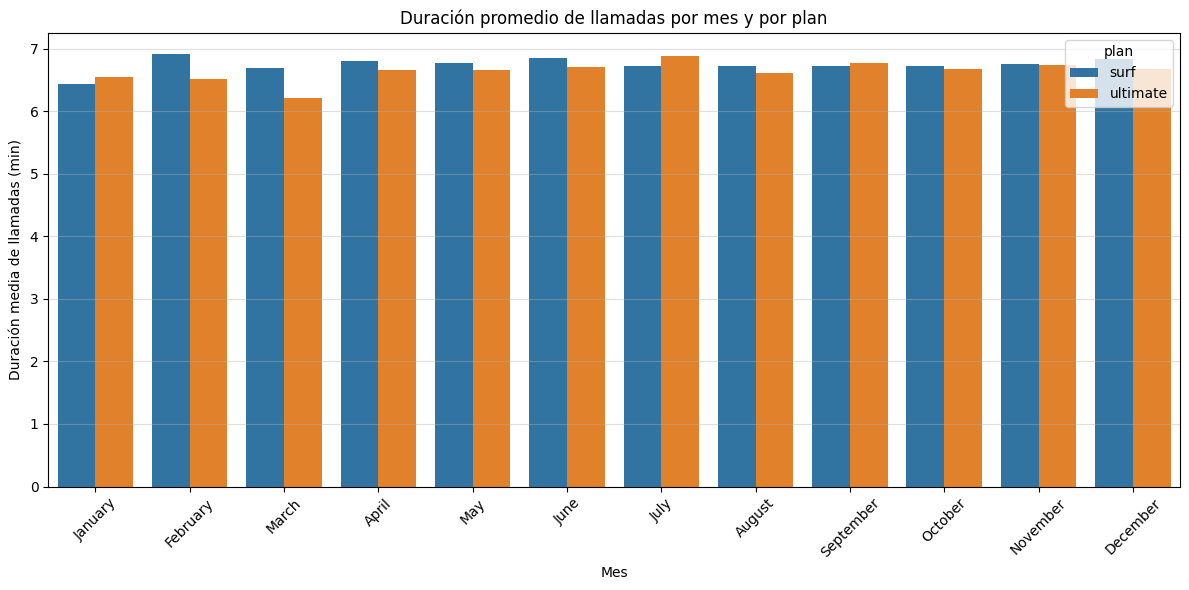

In [46]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

calls_users = calls.merge(users[['user_id', 'plan']], on='user_id', how='left')

calls_users['month'] = calls_users['call_date'].dt.month_name()

mean_calls = (
    calls_users
    .groupby(['month', 'plan'])['duration']
    .mean()
    .reset_index()
)

orden_meses = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

plt.figure(figsize=(12,6))

sns.barplot(
    data=mean_calls,
    x='month',
    y='duration',
    hue='plan',
    order=orden_meses
)
plt.grid(axis='y', alpha = 0.4)
plt.xticks(rotation=45)
plt.ylabel('Duración media de llamadas (min)')
plt.xlabel('Mes')
plt.title('Duración promedio de llamadas por mes y por plan')
plt.tight_layout()
plt.show()



En el histograma se compara el número de casos de los minutos utilizados al mes según el plan


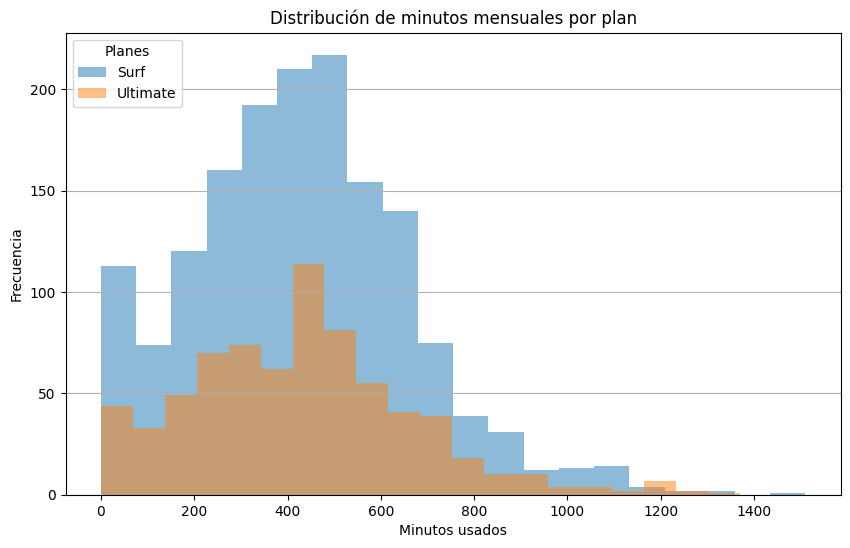

In [47]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
surf = monthly.loc[monthly['plan'] == 'surf'].reset_index()
ultimate = monthly.loc[monthly['plan'] == 'ultimate'].reset_index()
print()
print('En el histograma se compara el número de casos de los minutos utilizados al mes según el plan')

plt.figure(figsize=(10,6))
plt.hist(surf['minutes_used'], bins=20, label = 'Surf', alpha = 0.5)
plt.hist(ultimate['minutes_used'], bins=20, label = 'Ultimate', alpha = 0.5)
plt.legend(loc='upper left', title='Planes')
plt.title('Distribución de minutos mensuales por plan')
plt.xlabel('Minutos usados')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha = 1)

plt.show()


In [48]:
# Calculo del porcentaje de usuarios por plan por encima del limite de min
numero_user_surf = surf.shape[0]
numero_user_ultimate = ultimate.shape[0]

surf_min_out_lim = (surf.loc[surf['minutes_used'] > surf['minutes_included']]).shape[0]
ultimate_min_out_lim = (ultimate.loc[ultimate['minutes_used'] > ultimate['minutes_included']]).shape[0]

percent_surf_out_lim = (surf_min_out_lim / numero_user_surf) * 100
percent_ultimate_out_lim = (ultimate_min_out_lim / numero_user_ultimate) * 100
print('Porcentaje usuarios de plan Surf que gastan minutos por encima del limite: ', round(percent_surf_out_lim,2),'%')
print('Porcentaje usuarios de plan Ultimate que gastan minutos por encima del limite: ', round(percent_ultimate_out_lim,2),'%')

Porcentaje usuarios de plan Surf que gastan minutos por encima del limite:  35.85 %
Porcentaje usuarios de plan Ultimate que gastan minutos por encima del limite:  0.0 %


In [49]:
# Calcula la media y la varianza de la duración mensual de llamadas.
montly_calls_surf = monthly[monthly['plan'] == 'surf']
montly_calls_ultimate = monthly[monthly['plan'] == 'ultimate']

mean_duration_surf = montly_calls_surf['minutes_used'].mean()
var_duration_surf = montly_calls_surf['minutes_used'].var()
mean_duration_ultimate = montly_calls_ultimate['minutes_used'].mean()
var_duration_ultimate = montly_calls_ultimate['minutes_used'].var()
print('....Media y varianza de surf....')
print('Media de llamadas mensuales: ', round(mean_duration_surf,2), 'minutos')
print('Varianza de llamadas mensuales: ', round(var_duration_surf,2))
print()
print('....Media y varianza de ultimate....')
print('Valores de surf')
print('Media de llamadas mensuales: ', round(mean_duration_ultimate,2), 'minutos')
print('Varianza de llamadas mensuales: ', round(var_duration_ultimate,2))

....Media y varianza de surf....
Media de llamadas mensuales:  428.75 minutos
Varianza de llamadas mensuales:  54968.28

....Media y varianza de ultimate....
Valores de surf
Media de llamadas mensuales:  430.45 minutos
Varianza de llamadas mensuales:  57844.46


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

La métrica solicitada aquí es la media y la varianza de los minutos de llamadas *mensuales* por usuario (normalmente comparados por plan). Calcular la media/varianza de las duraciones de llamadas individuales a partir de la tabla `calls` sin procesar responde a una pregunta diferente, por lo que las conclusiones que siguen pueden estar basadas en un nivel de agregación incorrecto.

</div>


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Has calculado correctamente las métricas estadísticas básicas. Esto aporta una visión clara del comportamiento de los usuarios.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Como mejora, podrías complementar con percentiles o medianas, que a menudo son más robustas frente a valores extremos.

</div>

</div>

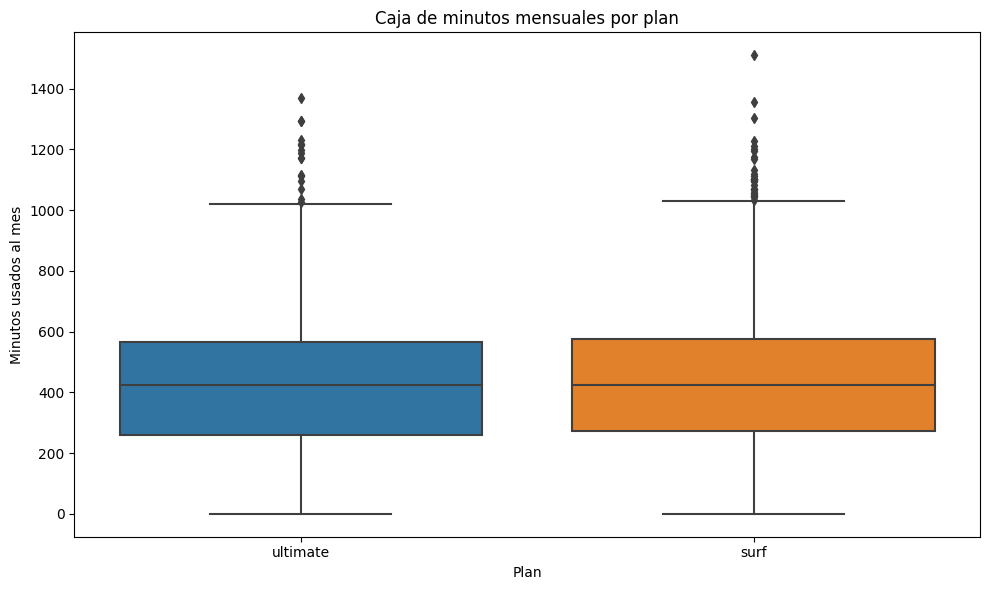

In [50]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
plt.figure(figsize=(10,6))

sns.boxplot(
    data=monthly,
    x='plan',
    y='minutes_used'
)

plt.xlabel('Plan')
plt.ylabel('Minutos usados al mes')
plt.title('Caja de minutos mensuales por plan')
plt.tight_layout()
plt.show()



- La duración media de llamadas parece indiferente al plan. Media de duración de llamadas: 6,75 minutos.
  
- La distribución de los minutos usados al mes parece bastante pareja, aunque haya más usuarios surf la forma de la distribución en cada plan es similar.

- El 35,8% de los usuarios del plan surf utilizan más minutos de los que incluye de base su tarifa.

- La media y varianza de la duración de las llamadas por mes tanto para surf como ultimate es identica aprox = 430 minutos de llamadas al mes.

- Las medianas de ambos planes están muy cerca, lo que indica que el usuario típico de Surf y Ultimate usa un número similar de minutos al mes.

- Hay valores atípicos que se pueden observar en la caja de bigotes, quiere decir que hay usuarios que usan muchos minutos de llamadas, estos valores existen igualmente en los dos planes. Por la posición de la mediana y el tamaño de los cuartiles se puede afirmar que no hay diferencia de comportamiento entre usuarios de distintos planes.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tus conclusiones sobre el comportamiento de llamadas se basan en estadísticas de duración **por llamada** en lugar de minutos mensuales **por usuario** según el plan. Vuelve a calcular la media/varianza usando la agregación por usuario-mes (e idealmente desglósalo por plan) y luego revisa la interpretación de las diferencias entre Surf y Ultimate.

</div>


### Mensajes

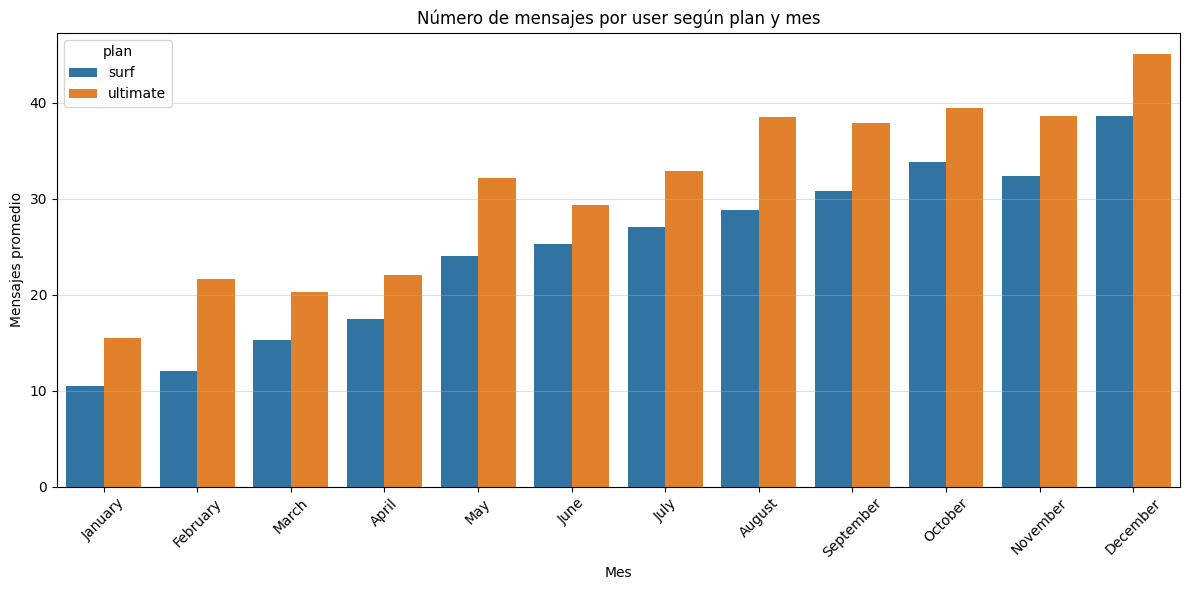

In [51]:
# Comprara el número promedio de mensajes que tienden a enviar cada mes los usuarios de cada plan

plt.figure(figsize=(12,6))

mean_messages = monthly.groupby(['month', 'plan'])['message_count'].mean().reset_index()

sns.barplot(
    data=mean_messages,
    x='month',
    y='message_count',
    hue='plan',
    order=orden_meses
)
plt.grid(axis='y', alpha = 0.4)
plt.xticks(rotation=45)
plt.ylabel('Mensajes promedio')
plt.xlabel('Mes')
plt.title('Número de mensajes por user según plan y mes')
plt.tight_layout()
plt.show()

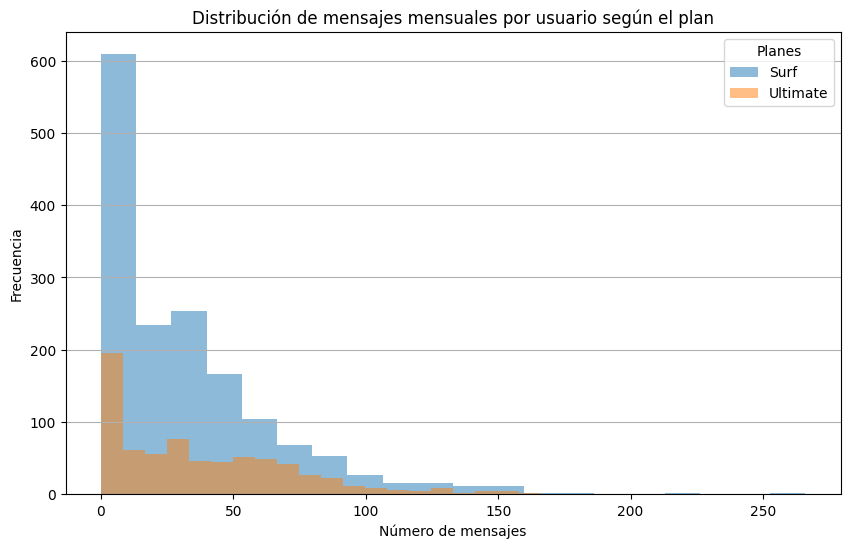

In [52]:
# Distribución de número de mensajes por usuario

plt.figure(figsize=(10,6))
plt.hist(surf['message_count'], bins=20, label = 'Surf', alpha = 0.5)
plt.hist(ultimate['message_count'], bins=20, label = 'Ultimate', alpha = 0.5)
plt.legend(loc='upper right', title='Planes')
plt.title('Distribución de mensajes mensuales por usuario según el plan')
plt.xlabel('Número de mensajes')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha = 1)

plt.show()



<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Este gráfico repite las distribuciones de mensajes, pero el flujo de la plantilla espera en esta parte del análisis una comparación del uso de Internet por plan. Considera mover este histograma de mensajes para mantener las secciones alineadas y añadir la comparación de Internet faltante donde se solicita.

</div>


In [53]:
# Calculo del porcentaje de usuarios por plan por encima del limite de messges_included
numero_user_surf = surf.shape[0]
numero_user_ultimate = ultimate.shape[0]

surf_messages_out_lim = (surf.loc[surf['message_count'] > surf['messages_included']]).shape[0]
ultimate_messages_out_lim = (ultimate.loc[ultimate['message_count'] > ultimate['messages_included']]).shape[0]

percent_surf_out_lim = (surf_messages_out_lim / numero_user_surf) * 100
percent_ultimate_out_lim = (ultimate_messages_out_lim / numero_user_ultimate) * 100
print('Porcentaje usuarios de plan Surf que gastan mensajes por encima del limite: ', round(percent_surf_out_lim,2),'%')
print('Porcentaje usuarios de plan Ultimate que gastan mensajes por encima del limite: ', round(percent_ultimate_out_lim,2),'%')

Porcentaje usuarios de plan Surf que gastan mensajes por encima del limite:  21.53 %
Porcentaje usuarios de plan Ultimate que gastan mensajes por encima del limite:  0.0 %


In [54]:
# Calculo de la media y la varianza de los mensajes enviados por mes.
messages_mean_duration = monthly['message_count'].mean()
messages_var_duration = monthly['message_count'].var()
print('Media de mensajes enviados al mes: ', round(messages_mean_duration,2))
print('Varianza de mensajes enviados al mes: ', round(messages_var_duration,2))

Media de mensajes enviados al mes:  33.17
Varianza de mensajes enviados al mes:  1160.77


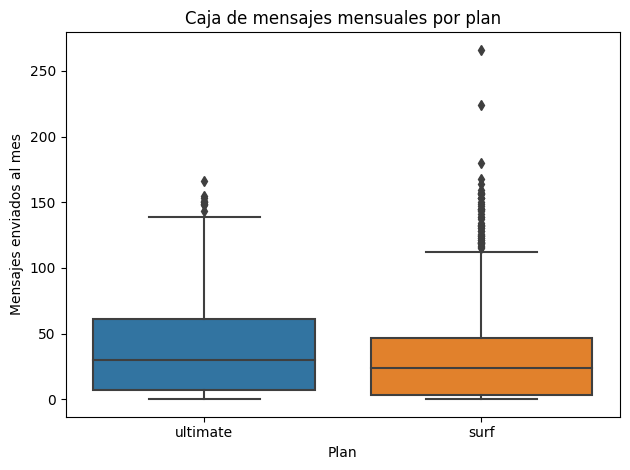

In [55]:
# Traza un diagrama de caja para visualizar la distribución de número de mensajes enviados por mes

sns.boxplot(
    data=monthly,
    x='plan',
    y='message_count'
)

plt.xlabel('Plan')
plt.ylabel('Mensajes enviados al mes')
plt.title('Caja de mensajes mensuales por plan')
plt.tight_layout()

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Excelente, describiste de manera clara las distribuciones y sus implicaciones.

</div>

- Para la media de mensajes enviados por plan se observa que los usuarios de ultimate envían más mensajes, también se puede observar un aumento del envio de mensajes mes a mes según avanza el año. La media de mensajes enviados por mes es 33.17
  
- Las distribuciones de los mensajes por mes tiene una forma bastante parecida entre planes, se observa una cola alta en valores bajos (gran parte de los usuarios envía pocos mensajes al mes), hay una pendiente a la baja en valores más altos, lo que indica que algunos usuarios exceden lo que incluye el plan.

- El 21.53 % del plan surf utilizan más mensajes de los incluidos en su tarifa.

- Para las cajas de bigotes por cada plan: la mediana es muy pareja entre los planes, hay un ligero repunte del uso de mensajes para los usuarios ultimate (según los cuartiles surf se cuida de no exceder los 50 mensajes de su tarifa)

### Internet

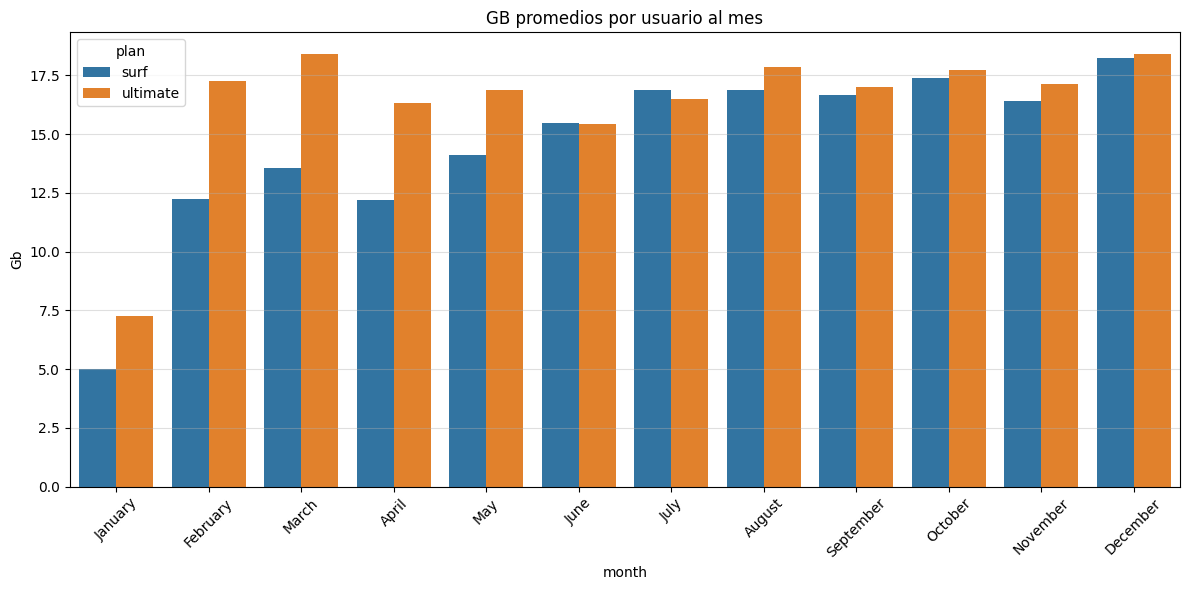

In [56]:
# Comprara la cantidad de tráfico de Internet promedio consumido por usuarios por plan

plt.figure(figsize=(12,6))

mean_internet = monthly.groupby(['month', 'plan'])['total_gb_month_round'].mean().reset_index()

sns.barplot(
    data=mean_internet,
    x='month',
    y='total_gb_month_round',
    hue='plan',
    order=orden_meses
)
plt.grid(axis='y', alpha = 0.4)
plt.xticks(rotation=45)
plt.ylabel('Gb')
plt.title('GB promedios por usuario al mes')
plt.tight_layout()
plt.show()

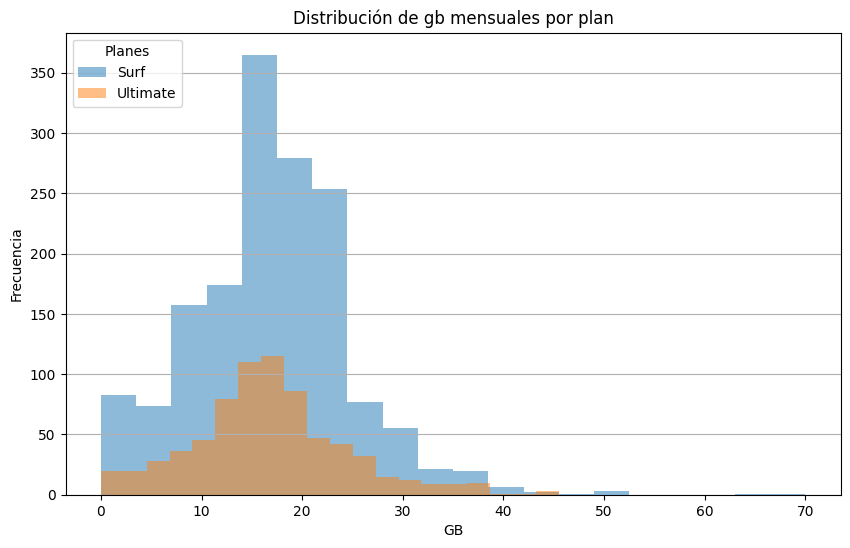

In [57]:
# Distribución de gb gastados por usuario al mes

plt.figure(figsize=(10,6))
plt.hist(surf['total_gb_month_round'], bins=20, label = 'Surf', alpha = 0.5)
plt.hist(ultimate['total_gb_month'], bins=20, label = 'Ultimate', alpha = 0.5)
plt.legend(loc='upper left', title='Planes')
plt.title('Distribución de gb mensuales por plan')
plt.xlabel('GB')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha = 1)

plt.show()



In [58]:
# Calculo del porcentaje de usuarios por plan por encima del limite de gb_included
numero_user_surf = surf.shape[0]
numero_user_ultimate = ultimate.shape[0]

surf_messages_out_lim = (surf.loc[surf['total_gb_month'] > surf['gb_per_month_included']]).shape[0]
ultimate_messages_out_lim = (ultimate.loc[ultimate['total_gb_month'] > ultimate['gb_per_month_included']]).shape[0]

percent_surf_out_lim = (surf_messages_out_lim / numero_user_surf) * 100
percent_ultimate_out_lim = (ultimate_messages_out_lim / numero_user_ultimate) * 100
print('Porcentaje usuarios de plan Surf que gastan gb por encima de la tarifa: ', round(percent_surf_out_lim,2),'%')
print('Porcentaje usuarios de plan Ultimate que gastan gb por encima de la tarifa: ', round(percent_ultimate_out_lim,2),'%')

Porcentaje usuarios de plan Surf que gastan gb por encima de la tarifa:  57.69 %
Porcentaje usuarios de plan Ultimate que gastan gb por encima de la tarifa:  5.66 %


In [59]:
# Calculo de la media y la varianza de los gb gastados por mes.
gb_mean_duration = monthly['total_gb_month'].mean()
gb_var_duration = monthly['total_gb_month'].var()
print('Media de gb gastados al mes: ', round(gb_mean_duration,2))
print('Varianza gb gastados al mes: ', round(gb_var_duration,2))

Media de gb gastados al mes:  16.37
Varianza gb gastados al mes:  60.54


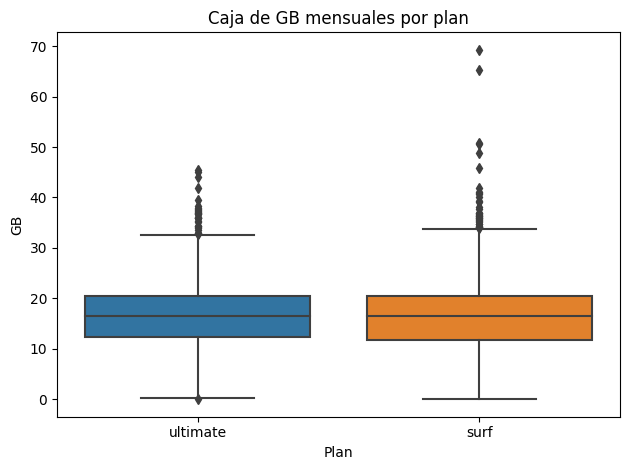

In [60]:
# Traza un diagrama de caja para visualizar la distribución gb por mes

sns.boxplot(
    data=monthly,
    x='plan',
    y='total_gb_month'
)

plt.xlabel('Plan')
plt.ylabel('GB')
plt.title('Caja de GB mensuales por plan')
plt.tight_layout()

- Los usuarios de ultimate consumen más internet al mes que surf, enero es el mes que menos consumo tiene.
  
- La forma entre las distribuciones de uso de internet se observa que tienen una forma muy similar lo que indica un comportamiento equivalente, independiente de la tarifa.

-  El 57.69 % de los usuarios surf excede el uso de gb de su tarifa.

-  El 5.66 % de los usuarios ultimate excede el uso de gb de su tarifa.

-  La media de gb gastados al mes por usuario es: 16.36 gb

-  Así como se aprecia en la distribución de uso de gb por mes, la caja indica un uso similar de internet, la mediana es la misma y el tamaño de los cuartiles también.

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Bien hecho, todos los graficos son correctos y permiten visualizar las distribuciones y detectar sesgos o valores atípicos. 

</div>

## Ingreso

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Reemplaza la instrucción de la plantilla entre corchetes con tu propia narrativa: resume las estadísticas de ingresos a nivel de plan (tendencia central + dispersión), lo que muestran los gráficos y la conclusión clave sobre qué plan genera más ingresos y por qué.

</div>


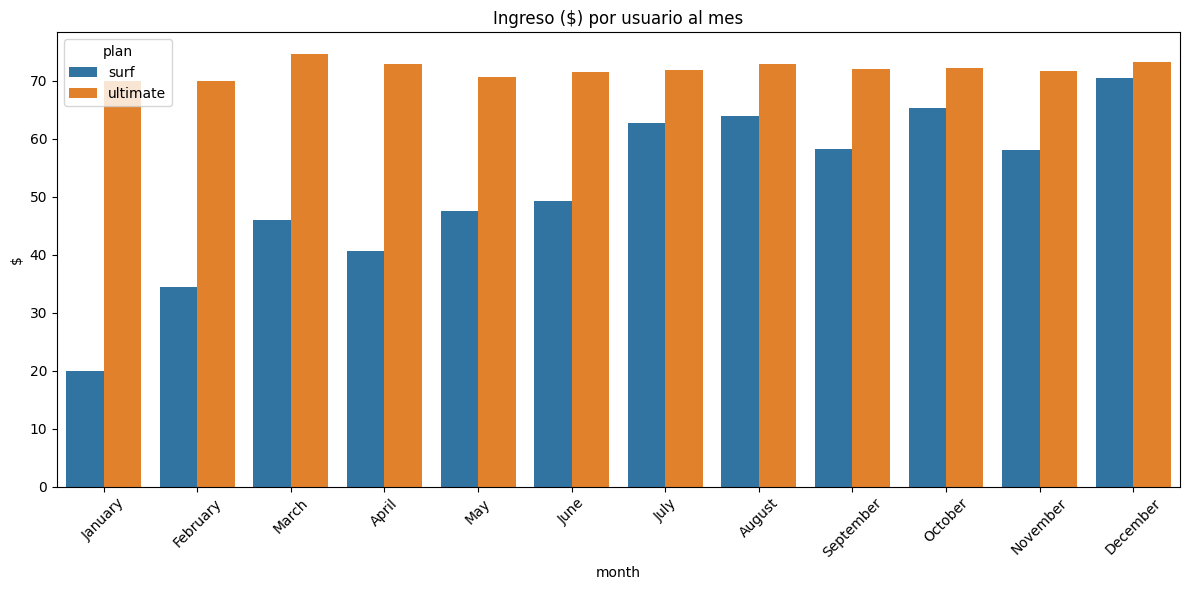

In [61]:
# Comprara el gasto promedio por usuario por plan al mes

plt.figure(figsize=(12,6))

mean_gasto = monthly.groupby(['month', 'plan'])['gasto_total_mes'].mean().reset_index()

sns.barplot(
    data=mean_gasto,
    x='month',
    y='gasto_total_mes',
    hue='plan',
    order=orden_meses
)

plt.xticks(rotation=45)
plt.ylabel('$')
plt.title('Ingreso ($) por usuario al mes')
plt.tight_layout()
plt.show()

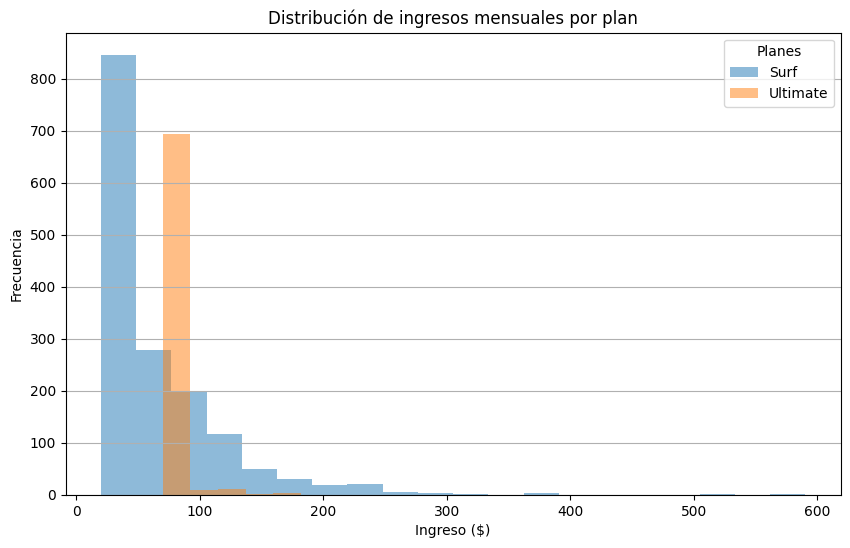

In [62]:
# Distribución de gasto por usuario al mes

plt.figure(figsize=(10,6))
plt.hist(surf['gasto_total_mes'], bins=20, label = 'Surf', alpha = 0.5)
plt.hist(ultimate['gasto_total_mes'], bins=5, label = 'Ultimate', alpha = 0.5)
plt.legend(loc='upper right', title='Planes')
plt.title('Distribución de ingresos mensuales por plan')
plt.xlabel('Ingreso ($)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha = 1)

plt.show()


In [63]:
# Calculo del porcentaje de usuarios por plan con el gasto por encima de la tarifa base
numero_user_surf = surf.shape[0]
numero_user_ultimate = ultimate.shape[0]

surf_messages_out_lim = (surf.loc[surf['gasto_total_mes'] > surf['usd_monthly_pay']]).shape[0]
ultimate_messages_out_lim = (ultimate.loc[ultimate['gasto_total_mes'] > ultimate['usd_monthly_pay']]).shape[0]

percent_surf_out_lim = (surf_messages_out_lim / numero_user_surf) * 100
percent_ultimate_out_lim = (ultimate_messages_out_lim / numero_user_ultimate) * 100
print('Porcentaje usuarios de plan Surf que gastan gb por encima del limite: ', round(percent_surf_out_lim,2),'%')
print('Porcentaje usuarios de plan Ultimate que gastan gb por encima del limite: ', round(percent_ultimate_out_lim,2),'%')

Porcentaje usuarios de plan Surf que gastan gb por encima del limite:  72.32 %
Porcentaje usuarios de plan Ultimate que gastan gb por encima del limite:  5.66 %


In [64]:
# Calculo de la media y la varianza del gasto por usuario por mes.
income_user_mean = monthly['gasto_total_mes'].mean()
income_user_var = monthly['gasto_total_mes'].var()
print('Media de ingresos al mes por usuario: ', round(income_user_mean,2))
print('Varianza de ingresos al mes porusuario: ', round(income_user_var,2))

Media de ingresos al mes por usuario:  64.35
Varianza de ingresos al mes porusuario:  2173.89


In [65]:
# Calcula la media y la varianza de la duración mensual de llamadas.
income_monthly_surf = monthly[monthly['plan'] == 'surf']
income_monthly_ultimate = monthly[monthly['plan'] == 'ultimate']

mean_income_surf = montly_calls_surf['gasto_total_mes'].mean()
var_income_surf = montly_calls_surf['gasto_total_mes'].var()
mean_income_ultimate = montly_calls_ultimate['gasto_total_mes'].mean()
var_income_ultimate = montly_calls_ultimate['gasto_total_mes'].var()
print('....Media y varianza de surf....')
print('Media de ingresos mensuales por usuario: $', round(mean_income_surf,2))
print('Varianza de ingresos mensuales por usuario: $', round(var_income_surf,2))
print()
print('....Media y varianza de ultimate....')
print('Valores de surf')
print('Media de ingresos mensuales por usuario: $', round(mean_income_ultimate,2))
print('Varianza de ingresos mensuales por usuario: $', round(var_income_ultimate,2))

....Media y varianza de surf....
Media de ingresos mensuales por usuario: $ 60.71
Varianza de ingresos mensuales por usuario: $ 3067.84

....Media y varianza de ultimate....
Valores de surf
Media de ingresos mensuales por usuario: $ 72.31
Varianza de ingresos mensuales por usuario: $ 129.85


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Para la sección de ingresos, calcula y reporta estadísticas descriptivas por plan (p. ej., mean/median/variance o std para Surf vs Ultimate). Ahora mismo, el mean/variance se calculan para todos los user-months combinados, lo cual no respalda directamente una comparación plan-to-plan.

</div>


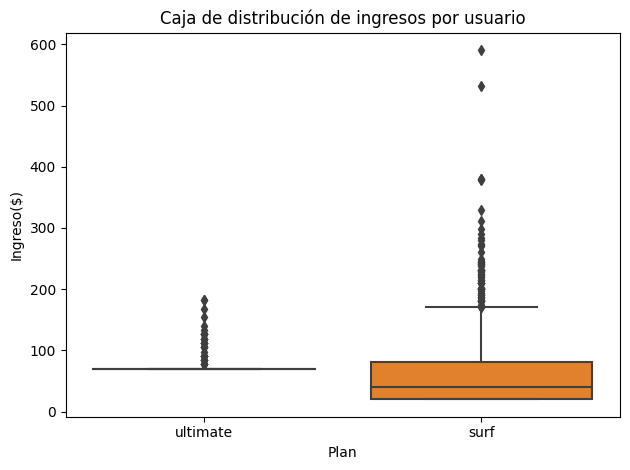

In [66]:
# Traza un diagrama de caja para visualizar la distribución de número de mensajes enviados por mes

sns.boxplot(
    data=monthly,
    x='plan',
    y='gasto_total_mes'
)

plt.xlabel('Plan')
plt.ylabel('Ingreso($)')
plt.title('Caja de distribución de ingresos por usuario')
plt.tight_layout()

- En el gráfico de barras de ingresos medios por mes se observa:
    Los ingresos de ultimate es practicamente el mismo todos los meses
    Los ingresos de surf van aumentando mes a mes, siendo enero el que parece ajustado al precio base de la tarifa.
  
- La distribución de ingresos mensuales por plan muestra:
    Los ingresos de ultimate están totalmente concentrados en el precio base de la tarifa `$70`
    Los ingresos de surf estan concentrados en el precio `$20`, se aprecia una cola descendente a la derecha que indica que los casos de ingresos por encima de la tarifa van disminuyendo según aumenta el ingreso.

- Porcentaje usuarios de plan Surf que gastan gb por encima del limite:  71.26 %

- Porcentaje usuarios de plan Ultimate que gastan gb por encima del limite:  5.61 %

- La caja de distribución muestra igual que la distribución, que los ingresos de ultimate son estables a la tarifa base.

- Sin embargo para el plan surf, si bien la mediana se ajusta a la tarifa base, hay un cuartil por encima de la mediana que indica que un número significativo de usuarios produce más ingresos por encima de su tarifa base.

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Tus conclusiones escritas comparan planes, pero en esta sección necesitan un respaldo numérico explícito (p. ej., ingresos mensuales promedio/mediana por plan y una medida de dispersión). Añadir esas cifras hará que el argumento sea más riguroso que basarse principalmente en visualizaciones.

</div>


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Vemos que los planes se diferencian en el ingreso, a pesar de que el consumo de sus usuarios es muy similar. Esto ocurre porque la estructura de costos de cada plan define intervalos de consumo diferentes, para surf los usuarios tienden a salirse de esos rangos pero los de ultimate no.

</div>

## Prueba las hipótesis estadísticas

Hipótesis nula: el ingreso promedio es igual según el plan

<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Planteaste las hipótesis.

<div class="alert alert-block alert-warning">  
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Un consejo: escribe siempre las hipótesis en lenguaje estadístico y en lenguaje simple para mayor claridad.

</div>

</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Indica explícitamente ambas hipótesis para la prueba de comparación de planes: H0 (el ingreso mensual promedio es igual entre los planes) y H1 (los promedios son diferentes). También menciona brevemente que esta es una prueba de dos colas (two-sided) porque estás evaluando cualquier diferencia, no una dirección específica.

</div>


In [67]:
# Prueba las hipótesis
surf_income = monthly[monthly['plan'] == 'surf']['gasto_total_mes']
ultimate_income = monthly[monthly['plan'] == 'ultimate']['gasto_total_mes']

In [68]:
# Elimino valores NaN de ambas muestras
surf_income_clean = surf_income.dropna()
ultimate_income_clean = ultimate_income.dropna()

# Verifico que ambas muestras tengan datos
print(f"Surf: {len(surf_income_clean)} registros")
print(f"Ultimate: {len(ultimate_income_clean)} registros")

Surf: 1573 registros
Ultimate: 720 registros


In [78]:
# La hipótesis nula es que el ingreso promedio por usuario es igual según el plan

alpha = 0.05  # el nivel de significancia estadística crítica
# si el valor p es menor que alpha, rechazamos la hipótesis

# realizo una prueba ttest_ind
results_h1 = st.ttest_ind(surf_income_clean, ultimate_income_clean, equal_var = False) 

print('valor p: ', results_h1.pvalue) # extraer el valor p

if results_h1.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")
print()
print('Gasto mensual medio por usuario surf: ','$', round(monthly[monthly['plan'] == 'surf']['gasto_total_mes'].mean(),2))
print('Gasto mensual medio por usuario ultimate: ', '$', round(monthly[monthly['plan'] == 'ultimate']['gasto_total_mes'].mean(),2))

valor p:  3.1703905481135734e-15
Rechazamos la hipótesis nula

Gasto mensual medio por usuario surf:  $ 60.71
Gasto mensual medio por usuario ultimate:  $ 72.31


- Al rechazar la hipótesis nula se puede afirmar que (para un valor de significancia del 5%) los ingresos promedios son diferentes según el plan.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Hay dos problemas que corregir aquí: (1) el código de comprobación de varianza tiene problemas de sintaxis/lógica (`Else` con mayúscula, y comparar varianzas con `!=` no tiene sentido), y (2) estás probando las muestras equivocadas: estás usando promedios mensuales por mes (≈12 puntos) en lugar de ingresos por usuario-mes. Usa los valores de ingresos por usuario-mes para cada plan como las dos muestras (y considera usar la prueba t de Welch por defecto si no estás seguro sobre varianzas iguales).

</div>


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Muy bien, seleccionaste un test estadístico coherente y lo aplicaste correctamente.

<div class="alert alert-block alert-warning"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Como mejora, explica siempre por qué elegiste ese test y qué supuestos tiene.

Además, recuerda que al realizar una prueba de hipótesis, es muy importante verificar los supuestos. El t-test que usaste funciona bien cuando se cumplen ciertos supuestos, como que las varianzas de ambos grupos (sábados lluviosos y no lluviosos) sean similares. Puedes realizar la prueba de levene para comprobar que los dos grupos tienen la misma varianza y, de esta forma, podrás saber el valor del parámetro equal_var que se debe utilizar en la función stats.ttest_ind.

</div>

</div>

Hipótesis nula: el ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.

In [70]:
# Añado la columna de users a monthly para consultar la región a traves de city_code
monthly = monthly.merge(
    users[['user_id', 'city_code']],
    on='user_id',
    how='left'
)

In [71]:
# Separo los datos según las regiones a probar en la hipótesis
ny_nj_monthly = (monthly[monthly['city_code'] == 'NY-NJ-PA'].groupby('month')['gasto_total_mes'].mean())
rest_monthly = (monthly[monthly['city_code'] != 'NY-NJ-PA'].groupby('month')['gasto_total_mes'].mean())

In [72]:
# Hipótesis nula: el ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.

alpha = 0.05  # nivel de significancia

# Prueba t de dos muestras independientes (Welch)
results_h2 = st.ttest_ind(ny_nj_monthly.values, rest_monthly.values, equal_var=False)

print("Valor p:", results_h2.pvalue)

# Decisión
if results_h2.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No se puede rechazar la hipótesis nula")

# Medias
print("Gasto mensual medio NY-NJ-PA: $", round(ny_nj_monthly.mean(), 2))
print("Gasto mensual medio resto de regiones: $", round(rest_monthly.mean(), 2))


Valor p: 0.07903841126977766
No se puede rechazar la hipótesis nula
Gasto mensual medio NY-NJ-PA: $ 53.92
Gasto mensual medio resto de regiones: $ 60.89


<div class="alert alert-block alert-success"> 
<b>Comentario del Revisor #2</b> <a class="tocSkip"></a>

Interpretaste los resultados con claridad, explicando su significado práctico.

Recuerda que la estadística es un medio, lo importante es qué significa para el negocio.

</div>

- Al no rechazar la hipótesis nula se puede afirmar que (para un valor de significancia del 5%) los ingresos promedios son iguales entre la region NY-NJ-PA y el resto.

## Conclusión general

## Propuesta de nueva tarifa para usuarios del plan surf con consumo excedido.

- Para favorecer la adherencia de clientes habría que ofrecer una alternativa intermedia a los usuarios de surf que exceden las condiciones incluidas en su tarifa.
- He decidido añadir una propuesta de tarifa alternativa para compensar el exceso de uso de conceptos limite para usuarios de surf, para evitar facturas excesivas.
- Según mi criterio una alternativa podría facilitar adhesión y permanencia de los clientes.

In [73]:
# Calculo la media mensual de consumo para los usuarios
numero_usuarios_surf_out_lim = monthly.groupby('user_id')['gasto_total_mes'].mean().reset_index(name = 'gasto_total')
# Fusiono para poder consultar los usuarios del plan surf
numero_usuarios_surf_out_lim = numero_usuarios_surf_out_lim.merge(
    users[['user_id', 'plan']],
    on='user_id',
    how='left')
# Consulto usuarios de plan surf que gastan por encima de la tarifa base
numero_usuarios_surf_out_lim = numero_usuarios_surf_out_lim.query('plan == "surf" & gasto_total > 20')
numero_usuarios_surf = users[users['plan'] == 'surf'].shape[0]
print(numero_usuarios_surf_out_lim.shape[0],'de', numero_usuarios_surf , 'usuarios del plan surf excenden su tarifa')

295 de 339 usuarios del plan surf excenden su tarifa


In [74]:
# Calculo de conceptos de la nueva tarifa ajustada a medianas.

users_surf = monthly[monthly['plan'] == 'surf']

users_surf_out_lim = users_surf[users_surf['gasto_total_mes'] > users_surf['usd_monthly_pay']]
median_calls_surf_out_lim = round(users_surf_out_lim['minutes_used'].median(),2)
median_gb_surf_out_lim = round(users_surf_out_lim['total_gb_month'].median(),2)
median_messages_out_lim = users_surf_out_lim['message_count'].median()

In [75]:
print('Los minutos mensuales en la nueva tarifa deberían rondar', median_calls_surf_out_lim, 'minutos mensuales')
print('Los gb mensuales en la nueva tarifa deberían rondar', median_gb_surf_out_lim, 'gb')
print('Los mensajes mensuales incluidos en la nueva tarifa deberían rondar', median_messages_out_lim, 'mensajes')

Los minutos mensuales en la nueva tarifa deberían rondar 497.5 minutos mensuales
Los gb mensuales en la nueva tarifa deberían rondar 18.42 gb
Los mensajes mensuales incluidos en la nueva tarifa deberían rondar 30.0 mensajes


Parece que el concepto de la tarifa que habría que ajustar son los gb mensuales incluidos, que superan la mediana al limite de 15gb de la tarifa y dispara el consumo mensual.

In [76]:
plans

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_per_mb,gb_per_month_included
0,50,15360,500,20,10,0.03,0.03,surf,0.009766,15.0
1,1000,30720,3000,70,7,0.01,0.01,ultimate,0.006836,30.0


In [77]:
# Propongo una tarifa de con 25gb mensuales, que es algo intermedio y superior a la mediana de consumo de gb
gb_mensuales_included_new = 25

proporcion_surf_nueva_tarifa = gb_mensuales_included_new / 15 # gb basicos de surf

messages_included_new = 50 * proporcion_surf_nueva_tarifa # 50 mensajes incluidos en surf (consultar tabla)

minutes_included_new = 500 * proporcion_surf_nueva_tarifa # 500 minutos de llamadas mensuales (consultar tabla)

usd_monthly_pay_new = 20 * proporcion_surf_nueva_tarifa # $20 de tarifa surf (consultar tabla)

print('....Resumen de tarifa propuesta....')
print()
print('Mensajes incluidos al mes: ', int(messages_included_new))
print('Minutos incluidos al mes: ', int(minutes_included_new))
print('GB incluidos al mes: ', int(gb_mensuales_included_new))
print('Precio: $',int(usd_monthly_pay_new))

....Resumen de tarifa propuesta....

Mensajes incluidos al mes:  83
Minutos incluidos al mes:  833
GB incluidos al mes:  25
Precio: $ 33


- Añadir que la técnica de redondeo es abusivo para el cliente, tanto el redondeo del gb como el de minuto "extra" por llamada individual. Al ser un caso de 2018 puede ser que las normas y protección al consumidor fueran otras o se aplicarán a discrección del proveedor.

- Desde mi punto de vista son practicas poco trasparentes que puede pasar desapercibidas para el usuario que no preste atención al detalle de su facturación.